# EDA

## SIMPLE STATS AND CLASS DISTRIBTUION

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('datasets/swmh/swmh.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54412 entries, 0 to 54411
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    54412 non-null  object
 1   label   54412 non-null  object
dtypes: object(2)
memory usage: 850.3+ KB


In [4]:
## COMMENTS -->
# i have 54.4 K records both text and label and no null
# data type is object

In [5]:
data.describe()

,text,label
count,54412,54412
unique,54299,5
top,FEARLESS FRIDAYS MEGA THREAD. Here we discuss ...,self.depression
freq,16,18746


In [6]:
## COMMENTS -->
# 54299 texts are unique and 113 text duplicate out of 54.4 K
# there are 54.4 K labels and there are 5 unique (catefories for those 54.4 K LABEL RECORDS)
# TOP :- FEARLESS FRIDAYS MEGA THREAD. Here we discuss this is most freq occuring text i.e 16 times and self.depression is the most freq occuring label 18746 times

In [7]:
data.head(5)

,text,label
0,wanting to skip or postpone my exam my exam is...,self.Anxiety
1,Do other bipolar folks have problems with subs...,self.bipolar
2,Wanted to share some revelations I just had to...,self.depression
3,I feel deader than dead. I find that I don't h...,self.SuicideWatch
4,I'm pretty sure my friends suicidal what do I ...,self.SuicideWatch


In [8]:
# classes and class districution
data['label'].value_counts(normalize = True)

label
self.depression      0.344520
self.SuicideWatch    0.187128
self.Anxiety         0.175605
self.offmychest      0.152246
self.bipolar         0.140502
Name: proportion, dtype: float64

In [9]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'classes and its distribution')

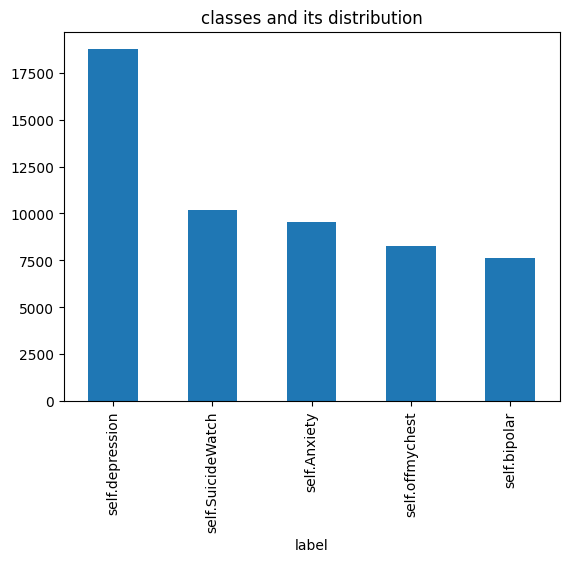

In [10]:
data['label'].value_counts().plot(kind='bar')
plt.title("classes and its distribution")

In [11]:
# THE CLASSES ARE 5 AND NOT BALANCED, HENCE USING STRATIFIED RANDOM SPLIT TO AVOID SYNTHETIC DATA 

## EDA--->TEXT PRE PROCESSING - STATELESS ON THE ENTIRE DATA SET

In [12]:
data['text'][0]

'wanting to skip or postpone my exam my exam is on saturday and i feel a massive urge to reschedule\r\n\r\ni experience this often with major exams. *flashbacks to several years prior where i skipped all of my final exams and failed* \r\n\r\ni just dont feel ready i dont know im so tired and mentallly fried that i feel a few days might help. but a part of me thinks i should fight this urge and just tank it'

In [13]:
## COMMENTS --> a alot of chracters and new line and new tab haracters as well, and many I and the like stopwords

#### LOWERCASSE

In [14]:
data['text_lowercase'] = data['text'].str.lower()

In [15]:
data['text'][3]


'I feel deader than dead. I find that I don\'t have real "wants" anymore. There would be a flicker of a desire that maybe I want to play Overwatch and it will be fun, but it fizzles as fast as it comes. I think for a moment that maybe I should feed myself. Then I just don\'t do it. Most days I end up curled up in bed, waiting for the hours to go by There are so many "shoulds" but nothink I *want* to so. An essay due monday? That\'s just another flicker of thought triggered by sheer sense of responsibility, not by my own conscious will. Besides, who cares about tests and essays when you\'re thinking about suicide. One week blurs into the next with only another bland weekend in which nothing happens in between. I feel deader than dead. I lived with it for a long while and was diagnosed when it developed suicidal after so many years. Child depression really goes unnoticed, especially because you yourself is not old and knowledgeable enough to recognize it as depression in the first place.

In [16]:
data['text_lowercase'][3]

'i feel deader than dead. i find that i don\'t have real "wants" anymore. there would be a flicker of a desire that maybe i want to play overwatch and it will be fun, but it fizzles as fast as it comes. i think for a moment that maybe i should feed myself. then i just don\'t do it. most days i end up curled up in bed, waiting for the hours to go by there are so many "shoulds" but nothink i *want* to so. an essay due monday? that\'s just another flicker of thought triggered by sheer sense of responsibility, not by my own conscious will. besides, who cares about tests and essays when you\'re thinking about suicide. one week blurs into the next with only another bland weekend in which nothing happens in between. i feel deader than dead. i lived with it for a long while and was diagnosed when it developed suicidal after so many years. child depression really goes unnoticed, especially because you yourself is not old and knowledgeable enough to recognize it as depression in the first place.

#### REMOVE STOPWORDS

In [17]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
eng_stopwords= stopwords.words('english')

In [19]:
eng_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [20]:
def remove_en_stopwords(text):
    joined_words = []
    for i in text.split():
        if i not in eng_stopwords:
            joined_words.append(i)
    return ' '.join(joined_words)
            

data['rmStopWords_text_lowercase'] = data['text_lowercase'].apply(remove_en_stopwords)

In [21]:
data['text_lowercase'][3]


'i feel deader than dead. i find that i don\'t have real "wants" anymore. there would be a flicker of a desire that maybe i want to play overwatch and it will be fun, but it fizzles as fast as it comes. i think for a moment that maybe i should feed myself. then i just don\'t do it. most days i end up curled up in bed, waiting for the hours to go by there are so many "shoulds" but nothink i *want* to so. an essay due monday? that\'s just another flicker of thought triggered by sheer sense of responsibility, not by my own conscious will. besides, who cares about tests and essays when you\'re thinking about suicide. one week blurs into the next with only another bland weekend in which nothing happens in between. i feel deader than dead. i lived with it for a long while and was diagnosed when it developed suicidal after so many years. child depression really goes unnoticed, especially because you yourself is not old and knowledgeable enough to recognize it as depression in the first place.

In [22]:
data['rmStopWords_text_lowercase'][3]


'feel deader dead. find real "wants" anymore. would flicker desire maybe want play overwatch fun, fizzles fast comes. think moment maybe feed myself. it. days end curled bed, waiting hours go many "shoulds" nothink *want* so. essay due monday? that\'s another flicker thought triggered sheer sense responsibility, conscious will. besides, cares tests essays thinking suicide. one week blurs next another bland weekend nothing happens between. feel deader dead. lived long diagnosed developed suicidal many years. child depression really goes unnoticed, especially old knowledgeable enough recognize depression first place. meds work lucky enough money buy them, know really help. logical side says another bottom-of-the-ocean-deep low phase unending cycle ups downs. real says whatever, want gone free pain life. reason held far parents. nothing deserve dead child. able repay love longest time medicine-run burden. wish could love back. love feel anything. hard feel pain, laugh, even cry anymore. d

In [23]:
## COMMENTS --> HERE THE TEXT DONT HAVE ANY STOP WRODS, BUT A LOT OF REGEX AND PUNCTAUTION

In [24]:
import re

In [25]:
def remove_punct(text):
    return re.sub(r'[^\w\s\']',' ', text)

data['rm punct_rmStopWords_text_lowercase'] = data['rmStopWords_text_lowercase'].apply(remove_punct)

In [26]:
data['rmStopWords_text_lowercase'][3]

'feel deader dead. find real "wants" anymore. would flicker desire maybe want play overwatch fun, fizzles fast comes. think moment maybe feed myself. it. days end curled bed, waiting hours go many "shoulds" nothink *want* so. essay due monday? that\'s another flicker thought triggered sheer sense responsibility, conscious will. besides, cares tests essays thinking suicide. one week blurs next another bland weekend nothing happens between. feel deader dead. lived long diagnosed developed suicidal many years. child depression really goes unnoticed, especially old knowledgeable enough recognize depression first place. meds work lucky enough money buy them, know really help. logical side says another bottom-of-the-ocean-deep low phase unending cycle ups downs. real says whatever, want gone free pain life. reason held far parents. nothing deserve dead child. able repay love longest time medicine-run burden. wish could love back. love feel anything. hard feel pain, laugh, even cry anymore. d

In [27]:
data['rm punct_rmStopWords_text_lowercase'][3]

"feel deader dead  find real  wants  anymore  would flicker desire maybe want play overwatch fun  fizzles fast comes  think moment maybe feed myself  it  days end curled bed  waiting hours go many  shoulds  nothink  want  so  essay due monday  that's another flicker thought triggered sheer sense responsibility  conscious will  besides  cares tests essays thinking suicide  one week blurs next another bland weekend nothing happens between  feel deader dead  lived long diagnosed developed suicidal many years  child depression really goes unnoticed  especially old knowledgeable enough recognize depression first place  meds work lucky enough money buy them  know really help  logical side says another bottom of the ocean deep low phase unending cycle ups downs  real says whatever  want gone free pain life  reason held far parents  nothing deserve dead child  able repay love longest time medicine run burden  wish could love back  love feel anything  hard feel pain  laugh  even cry anymore  dr

In [28]:
## COMMENTS --> THE PUCTIONS AND ASTERIK ARE GONE, HENCE SIMPLFING THE TEXT FOR ALGO

In [29]:
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [30]:
def word_tokenizery(text):
    return word_tokenize(text)

data['token_punct_rmStopWords_text_lowercase'] = data['rm punct_rmStopWords_text_lowercase'].apply(word_tokenizery)

In [31]:
data['rm punct_rmStopWords_text_lowercase'][3]

"feel deader dead  find real  wants  anymore  would flicker desire maybe want play overwatch fun  fizzles fast comes  think moment maybe feed myself  it  days end curled bed  waiting hours go many  shoulds  nothink  want  so  essay due monday  that's another flicker thought triggered sheer sense responsibility  conscious will  besides  cares tests essays thinking suicide  one week blurs next another bland weekend nothing happens between  feel deader dead  lived long diagnosed developed suicidal many years  child depression really goes unnoticed  especially old knowledgeable enough recognize depression first place  meds work lucky enough money buy them  know really help  logical side says another bottom of the ocean deep low phase unending cycle ups downs  real says whatever  want gone free pain life  reason held far parents  nothing deserve dead child  able repay love longest time medicine run burden  wish could love back  love feel anything  hard feel pain  laugh  even cry anymore  dr

In [32]:
data['token_punct_rmStopWords_text_lowercase'][3]

['feel',
 'deader',
 'dead',
 'find',
 'real',
 'wants',
 'anymore',
 'would',
 'flicker',
 'desire',
 'maybe',
 'want',
 'play',
 'overwatch',
 'fun',
 'fizzles',
 'fast',
 'comes',
 'think',
 'moment',
 'maybe',
 'feed',
 'myself',
 'it',
 'days',
 'end',
 'curled',
 'bed',
 'waiting',
 'hours',
 'go',
 'many',
 'shoulds',
 'nothink',
 'want',
 'so',
 'essay',
 'due',
 'monday',
 'that',
 "'s",
 'another',
 'flicker',
 'thought',
 'triggered',
 'sheer',
 'sense',
 'responsibility',
 'conscious',
 'will',
 'besides',
 'cares',
 'tests',
 'essays',
 'thinking',
 'suicide',
 'one',
 'week',
 'blurs',
 'next',
 'another',
 'bland',
 'weekend',
 'nothing',
 'happens',
 'between',
 'feel',
 'deader',
 'dead',
 'lived',
 'long',
 'diagnosed',
 'developed',
 'suicidal',
 'many',
 'years',
 'child',
 'depression',
 'really',
 'goes',
 'unnoticed',
 'especially',
 'old',
 'knowledgeable',
 'enough',
 'recognize',
 'depression',
 'first',
 'place',
 'meds',
 'work',
 'lucky',
 'enough',
 'money

In [33]:
## COMENT --> THE WORDS ARE TOKENIZED AND NOW LETS LEMMATIZE

In [34]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [35]:
lemma = WordNetLemmatizer()
def lemmatizewird(token):
    lemmaken = []
    for i in token:
        lemmaken.append(lemma.lemmatize(i))
    return lemmaken

data['lemm_token_punct_rmStopWords_text_lowercase'] = data['token_punct_rmStopWords_text_lowercase'].apply(lemmatizewird)

In [36]:
data['token_punct_rmStopWords_text_lowercase'][3]

['feel',
 'deader',
 'dead',
 'find',
 'real',
 'wants',
 'anymore',
 'would',
 'flicker',
 'desire',
 'maybe',
 'want',
 'play',
 'overwatch',
 'fun',
 'fizzles',
 'fast',
 'comes',
 'think',
 'moment',
 'maybe',
 'feed',
 'myself',
 'it',
 'days',
 'end',
 'curled',
 'bed',
 'waiting',
 'hours',
 'go',
 'many',
 'shoulds',
 'nothink',
 'want',
 'so',
 'essay',
 'due',
 'monday',
 'that',
 "'s",
 'another',
 'flicker',
 'thought',
 'triggered',
 'sheer',
 'sense',
 'responsibility',
 'conscious',
 'will',
 'besides',
 'cares',
 'tests',
 'essays',
 'thinking',
 'suicide',
 'one',
 'week',
 'blurs',
 'next',
 'another',
 'bland',
 'weekend',
 'nothing',
 'happens',
 'between',
 'feel',
 'deader',
 'dead',
 'lived',
 'long',
 'diagnosed',
 'developed',
 'suicidal',
 'many',
 'years',
 'child',
 'depression',
 'really',
 'goes',
 'unnoticed',
 'especially',
 'old',
 'knowledgeable',
 'enough',
 'recognize',
 'depression',
 'first',
 'place',
 'meds',
 'work',
 'lucky',
 'enough',
 'money

In [37]:
data['lemm_token_punct_rmStopWords_text_lowercase'][3]

['feel',
 'deader',
 'dead',
 'find',
 'real',
 'want',
 'anymore',
 'would',
 'flicker',
 'desire',
 'maybe',
 'want',
 'play',
 'overwatch',
 'fun',
 'fizzle',
 'fast',
 'come',
 'think',
 'moment',
 'maybe',
 'feed',
 'myself',
 'it',
 'day',
 'end',
 'curled',
 'bed',
 'waiting',
 'hour',
 'go',
 'many',
 'shoulds',
 'nothink',
 'want',
 'so',
 'essay',
 'due',
 'monday',
 'that',
 "'s",
 'another',
 'flicker',
 'thought',
 'triggered',
 'sheer',
 'sense',
 'responsibility',
 'conscious',
 'will',
 'besides',
 'care',
 'test',
 'essay',
 'thinking',
 'suicide',
 'one',
 'week',
 'blur',
 'next',
 'another',
 'bland',
 'weekend',
 'nothing',
 'happens',
 'between',
 'feel',
 'deader',
 'dead',
 'lived',
 'long',
 'diagnosed',
 'developed',
 'suicidal',
 'many',
 'year',
 'child',
 'depression',
 'really',
 'go',
 'unnoticed',
 'especially',
 'old',
 'knowledgeable',
 'enough',
 'recognize',
 'depression',
 'first',
 'place',
 'med',
 'work',
 'lucky',
 'enough',
 'money',
 'buy',
 '

In [38]:
data['lemm_token_punct_rmStopWords_text_lowercase']

0        [wanting, skip, postpone, exam, exam, saturday...
1        [bipolar, folk, problem, substance, abuse, fir...
2        [wanted, share, revelation, tonight, depressio...
3        [feel, deader, dead, find, real, want, anymore...
4        [pretty, sure, friend, suicidal, do, best, fri...
                               ...                        
54407    [stopped, lamictal, screwed, vision, long, sid...
54408    [afraid, ex, committed, suicide, short, story,...
54409    [failed, college, 2, time, 10, year, ago, hate...
54410    [put, music, find, beautiful, go, walk, smell,...
54411    [discovered, friend, made, blog, today, posted...
Name: lemm_token_punct_rmStopWords_text_lowercase, Length: 54412, dtype: object

In [39]:
## COMMENT --> THE WANTS BECAME WANT, FIZZELES BECAME FIZZLE

In [40]:
# data['list_lemm_token_punct_rmStopWords_text_lowercase'] = sum(data['lemm_token_punct_rmStopWords_text_lowercase'], [])
# With 54,412 documents, the flattened list could contain millions of tokens. Example:

#Using pandas explode (Good for DataFrames)
# If data is a DataFrame, not a Series
list_lemm_token_punct_rmStopWords_text_lowercase = data['lemm_token_punct_rmStopWords_text_lowercase'].explode().tolist()

In [41]:
len(list_lemm_token_punct_rmStopWords_text_lowercase)

4949353

In [42]:
unigram = nltk.ngrams(list_lemm_token_punct_rmStopWords_text_lowercase,1)

In [43]:
import pandas as pd
unigram_series_col = pd.Series(unigram)
unigram_series_col

0             (wanting,)
1                (skip,)
2            (postpone,)
3                (exam,)
4                (exam,)
               ...      
4949348        (posted,)
4949349     (something,)
4949350    (disturbing,)
4949351          (help,)
4949352       (deleted,)
Length: 4949353, dtype: object

In [44]:
unigram_series_col.value_counts() # ferq

(like,)              60657
(feel,)              53353
(i,)                 43220
(know,)              42179
(want,)              39973
                     ...  
(doage,)                 1
(healthly,)              1
(comcerned,)             1
(overshaddowing,)        1
(passersby,)             1
Name: count, Length: 51139, dtype: int64

In [45]:
bigram = nltk.ngrams(list_lemm_token_punct_rmStopWords_text_lowercase,2)

In [46]:
bigram_series_col = pd.Series(bigram)
bigram_series_col

0                  (wanting, skip)
1                 (skip, postpone)
2                 (postpone, exam)
3                     (exam, exam)
4                 (exam, saturday)
                    ...           
4949347            (today, posted)
4949348        (posted, something)
4949349    (something, disturbing)
4949350         (disturbing, help)
4949351            (help, deleted)
Length: 4949352, dtype: object

In [47]:
bigram_series_col.value_counts() # ferq

(i, m)                  22426
(feel, like)            20366
(ca, n't)               19612
(don, t)                11322
(i, ve)                  8149
                        ...  
(prize, 10)                 1
(first, prize)              1
(ceremony, next)            1
(revealed, ceremony)        1
(disturbing, help)          1
Name: count, Length: 1680569, dtype: int64

In [48]:
trigrams = nltk.ngrams(list_lemm_token_punct_rmStopWords_text_lowercase,3)

In [49]:
trigrma_series_col = pd.Series(trigrams)
trigrma_series_col

0                (wanting, skip, postpone)
1                   (skip, postpone, exam)
2                   (postpone, exam, exam)
3                   (exam, exam, saturday)
4                   (exam, saturday, feel)
                        ...               
4949346              (blog, today, posted)
4949347         (today, posted, something)
4949348    (posted, something, disturbing)
4949349      (something, disturbing, help)
4949350        (disturbing, help, deleted)
Length: 4949351, dtype: object

In [50]:
trigrma_series_col.value_counts()

(don, t, know)                    2900
(don, t, want)                    1816
(ca, n't, even)                   1254
(i, m, going)                     1046
(like, i, m)                      1045
                                  ... 
(became, difficult, relate)          1
(difficult, relate, classmate)       1
(relate, classmate, end)             1
(classmate, end, feeling)            1
(disturbing, help, deleted)          1
Name: count, Length: 4053270, dtype: int64

Bigram	(want, die)	Less context

Trigram	(i, want, die)	Full suicidal statement

Bigram	(feel, numb)	Vague

Trigram	(i, feel, numb)	Personal experience

In [51]:
#COMMENT -->  2900 times (uncertainty, confusion)...1046 times (future statements, often negative)

## EDA 2 --> SINCE THE DATA IS TOO LONG LETS DO NER/POS ANAYSLIS AFTER SPLIT AND PROBABLY ONLY ON THE TRAIN DATA (FOR NOW TO TRAIN THE MODEL)

### SPLIT

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
# First split: separate test set (e.g., 20% of total)
train_val_data, test = train_test_split ( ## here since test is second vart, we are spltting that
    data, ## the df 
    test_size=0.2, ## the test dataset size
    stratify = data['label'], #] ensures that the class proportions (percentage of each label) are preserved across all splits.
    random_state=26
)

In [54]:
train_val_data.head()

,text,label,text_lowercase,rmStopWords_text_lowercase,rm punct_rmStopWords_text_lowercase,token_punct_rmStopWords_text_lowercase,lemm_token_punct_rmStopWords_text_lowercase
7516,Trying to take it slow with a new relationship...,self.bipolar,trying to take it slow with a new relationship...,trying take slow new relationship intense firs...,trying take slow new relationship intense firs...,"[trying, take, slow, new, relationship, intens...","[trying, take, slow, new, relationship, intens..."
14914,Our university is having finals and we're surr...,self.offmychest,our university is having finals and we're surr...,university finals surrounded 3 major fires. no...,university finals surrounded 3 major fires no...,"[university, finals, surrounded, 3, major, fir...","[university, final, surrounded, 3, major, fire..."
3235,Came to a realization today Today I had rememb...,self.depression,came to a realization today today i had rememb...,came realization today today remembered twilig...,came realization today today remembered twilig...,"[came, realization, today, today, remembered, ...","[came, realization, today, today, remembered, ..."
50907,The worst thing about being Bipolar: (Hallunci...,self.bipolar,the worst thing about being bipolar: (hallunci...,worst thing bipolar: (halluncinations) questio...,worst thing bipolar halluncinations questio...,"[worst, thing, bipolar, halluncinations, quest...","[worst, thing, bipolar, halluncinations, quest..."
50815,"My last sleep maybe? Well, I think this could ...",self.SuicideWatch,"my last sleep maybe? well, i think this could ...","last sleep maybe? well, think could it. night ...",last sleep maybe well think could it night ...,"[last, sleep, maybe, well, think, could, it, n...","[last, sleep, maybe, well, think, could, it, n..."


In [55]:
test.head()

,text,label,text_lowercase,rmStopWords_text_lowercase,rm punct_rmStopWords_text_lowercase,token_punct_rmStopWords_text_lowercase,lemm_token_punct_rmStopWords_text_lowercase
29408,I just know that the amount of time it's gonna...,self.offmychest,i just know that the amount of time it's gonna...,know amount time gonna take fully get breakup ...,know amount time gonna take fully get breakup ...,"[know, amount, time, gon, na, take, fully, get...","[know, amount, time, gon, na, take, fully, get..."
10835,Alone on NYE for the first time in 4 years I f...,self.Anxiety,alone on nye for the first time in 4 years i f...,alone nye first time 4 years feel really anxio...,alone nye first time 4 years feel really anxio...,"[alone, nye, first, time, 4, years, feel, real...","[alone, nye, first, time, 4, year, feel, reall..."
46330,Does anyone else have anxiety that comes and g...,self.Anxiety,does anyone else have anxiety that comes and g...,anyone else anxiety comes goes unpredictably t...,anyone else anxiety comes goes unpredictably t...,"[anyone, else, anxiety, comes, goes, unpredict...","[anyone, else, anxiety, come, go, unpredictabl..."
42660,Anyone try Brintellix/Trintellix I’ve tried Pr...,self.depression,anyone try brintellix/trintellix i’ve tried pr...,anyone try brintellix/trintellix i’ve tried pr...,anyone try brintellix trintellix i ve tried pr...,"[anyone, try, brintellix, trintellix, i, ve, t...","[anyone, try, brintellix, trintellix, i, ve, t..."
27355,I feel like there's something wrong with me Th...,self.depression,i feel like there's something wrong with me th...,feel like there's something wrong there's feel...,feel like there's something wrong there's feel...,"[feel, like, there, 's, something, wrong, ther...","[feel, like, there, 's, something, wrong, ther..."


In [56]:
# Second split: split train_val into train (70% of original) and val (10% of original)
# This makes: train = 70%, val = 10%, test = 20%
train, val = train_test_split(
    train_val_data, ## this is the remaining dataset from the avoe split,
    test_size = 0.125, ## 0.125 * 0.8 = 0.1 (10% of total)
    stratify = train_val_data['label'], #You use stratify=train_val['label'] because train_val is the only data available at that moment - the test set has already been removed.
    random_state =26
)

In [57]:
train.head()

,text,label,text_lowercase,rmStopWords_text_lowercase,rm punct_rmStopWords_text_lowercase,token_punct_rmStopWords_text_lowercase,lemm_token_punct_rmStopWords_text_lowercase
46746,My life has fallen apart again and I have no m...,self.SuicideWatch,my life has fallen apart again and i have no m...,life fallen apart strength left growing family...,life fallen apart strength left growing family...,"[life, fallen, apart, strength, left, growing,...","[life, fallen, apart, strength, left, growing,..."
17447,"Man, I hate having this illness!!!!😩😩 Was diag...",self.bipolar,"man, i hate having this illness!!!!😩😩 was diag...","man, hate illness!!!!😩😩 diagnosed bipolar 17, ...",man hate illness diagnosed bipolar 17 ...,"[man, hate, illness, diagnosed, bipolar, 17, g...","[man, hate, illness, diagnosed, bipolar, 17, g..."
46449,I’ve had sex with 4 different guys in my paren...,self.offmychest,i’ve had sex with 4 different guys in my paren...,i’ve sex 4 different guys parents bed. [deleted],i ve sex 4 different guys parents bed deleted,"[i, ve, sex, 4, different, guys, parents, bed,...","[i, ve, sex, 4, different, guy, parent, bed, d..."
20667,Emotional torture is taught Those who have bee...,self.depression,emotional torture is taught those who have bee...,emotional torture taught tortured derive pleas...,emotional torture taught tortured derive pleas...,"[emotional, torture, taught, tortured, derive,...","[emotional, torture, taught, tortured, derive,..."
29040,Getting this off my chest. I'm writing this as...,self.depression,getting this off my chest. i'm writing this as...,getting chest. writing midnight creeps night s...,getting chest writing midnight creeps night s...,"[getting, chest, writing, midnight, creeps, ni...","[getting, chest, writing, midnight, creep, nig..."


In [58]:
val.head()

,text,label,text_lowercase,rmStopWords_text_lowercase,rm punct_rmStopWords_text_lowercase,token_punct_rmStopWords_text_lowercase,lemm_token_punct_rmStopWords_text_lowercase
30101,I feel like I can't keep going Hey everyone. S...,self.SuicideWatch,i feel like i can't keep going hey everyone. s...,feel like can't keep going hey everyone. know ...,feel like can't keep going hey everyone know ...,"[feel, like, ca, n't, keep, going, hey, everyo...","[feel, like, ca, n't, keep, going, hey, everyo..."
52962,I went to the doctor a little over a year now ...,self.depression,i went to the doctor a little over a year now ...,went doctor little year thought depression jac...,went doctor little year thought depression jac...,"[went, doctor, little, year, thought, depressi...","[went, doctor, little, year, thought, depressi..."
19893,Always seeking affection and assurance in my r...,self.Anxiety,always seeking affection and assurance in my r...,always seeking affection assurance relationshi...,always seeking affection assurance relationshi...,"[always, seeking, affection, assurance, relati...","[always, seeking, affection, assurance, relati..."
53830,"Defined by depression, negatively but also pos...",self.depression,"defined by depression, negatively but also pos...","defined depression, negatively also positively...",defined depression negatively also positively...,"[defined, depression, negatively, also, positi...","[defined, depression, negatively, also, positi..."
31709,"My kid is sick, and I feel like I'm going craz...",self.offmychest,"my kid is sick, and i feel like i'm going craz...","kid sick, feel like going crazy. little one si...",kid sick feel like going crazy little one si...,"[kid, sick, feel, like, going, crazy, little, ...","[kid, sick, feel, like, going, crazy, little, ..."


In [59]:
# Check sizes
print(f"TRAIN : {len(train)} Samples")
print(f"TEST : {len(test)} Samples")
print(f"VALIDATION : {len(val)} Samples")

TRAIN : 38087 Samples
TEST : 10883 Samples
VALIDATION : 5442 Samples


In [60]:
# Verify stratification
print("\n TRAIN DATASET 5 CLASS/LABEL DISTRIBUTION")
print(train['label'].value_counts(normalize= True))

print("\n TEST DATASET 5 CLASS/LABEL DISTRIBUTION")
print(test['label'].value_counts(normalize= True))

print("\n VALIDATION DATASET 5 CLASS/LABEL DISTRIBUTION")
print(val['label'].value_counts(normalize= True))


 TRAIN DATASET 5 CLASS/LABEL DISTRIBUTION
label
self.depression      0.344527
self.SuicideWatch    0.187124
self.Anxiety         0.175598
self.offmychest      0.152257
self.bipolar         0.140494
Name: proportion, dtype: float64

 TEST DATASET 5 CLASS/LABEL DISTRIBUTION
label
self.depression      0.344482
self.SuicideWatch    0.187173
self.Anxiety         0.175595
self.offmychest      0.152256
self.bipolar         0.140494
Name: proportion, dtype: float64

 VALIDATION DATASET 5 CLASS/LABEL DISTRIBUTION
label
self.depression      0.344542
self.SuicideWatch    0.187064
self.Anxiety         0.175671
self.offmychest      0.152150
self.bipolar         0.140573
Name: proportion, dtype: float64


### EDA ---> NER AND POS ANALYSIS 

In [61]:
import spacy
nlp = spacy.load('en_core_web_sm')

#### HERE NOW CREATING SPACY DOC FOR TRAIN DOC (DATA SET) and since my tain doc has many row (nlp pipe) ther is just 1 row in doc tehen (nlp(that doc))

In [62]:
train_texts = train['text'].tolist() # this becomes one list with all the text from tain doc text collums

In [63]:
#This creates a list of SpaCy Doc objects. Each Doc contains:

#✅ Tokens

#✅ POS tags

#✅ Dependency parse

#✅ NER entities

#✅ Word vectors (if using 'md' or 'lg' model)
spacy_doc_train_doc = list(nlp.pipe(train_texts,batch_size=100))

In [70]:
len(spacy_doc_train_doc) # 38087 docs so probably 1 doc has 1 text/row

38087

In [82]:
#extract all the SpaCy features from your docs
def extract_token_and_tag(doc: spacy.tokens.doc.Doc):
        return [
            (
            i.text,           # token
            i.lemma_,         # lemma
            i.pos_,           # coarse POS
            i.tag_,           # fine-grained POS
            i.dep_,           # dependency
            i.ent_type_,      # NER entity
            i.ent_iob_,       # NER IOB
            i.is_stop,        # is stopword?
            i.shape_          # word shape
            ) for i in doc
        ]

In [83]:
# List of DataFrames
pos_token_dfs = []
columns = ['token', 'lemma', 'pos', 'tag', 'dep', 'ner_type', 'ner_iob', 'is_stop', 'shape']

In [87]:
for ix, doc in enumerate(spacy_doc_train_doc[:100]):
    features = extract_token_and_tag(doc)
    df = pd.DataFrame(features, columns=columns)
    pos_token_dfs.append(df)

In [89]:
# Check first document
print(f"Document 0 has {len(pos_token_dfs[0])} tokens")
print(pos_token_dfs[0].head(10))

Document 0 has 670 tokens
    token  lemma    pos   tag     dep ner_type ner_iob  is_stop shape
0      My     my   PRON  PRP$    poss                O     True    Xx
1    life   life   NOUN    NN   nsubj                O    False  xxxx
2     has   have    AUX   VBZ     aux                O     True   xxx
3  fallen   fall   VERB   VBN    ROOT                O    False  xxxx
4   apart  apart    ADV    RB  advmod                O    False  xxxx
5   again  again    ADV    RB  advmod                O     True  xxxx
6     and    and  CCONJ    CC      cc                O     True   xxx
7       I      I   PRON   PRP   nsubj                O     True     X
8    have   have   VERB   VBP    conj                O     True  xxxx
9      no     no    DET    DT     det                O     True    xx
